# 03 — ABP y ABF en una dimensión: potencial, muestreo y energía libre

Este notebook convierte el caso de doble pozo en un ejemplo científico y
reproducible. Toda la dinámica procede de `src/stage_escape`; aquí solo se
definen parámetros, se ejecutan casos de referencia y se construyen diagnósticos.

Se estudian:

1. el potencial físico y la distribución de Boltzmann;
2. el aplanamiento progresivo producido por ABP;
3. la corrección de la distribución mediante reponderación;
4. la estimación de \(V'(x)\), la cobertura y la energía libre con ABF.

`QUICK_MODE=True` produce una ejecución exploratoria. Para figuras finales del
informe debe usarse `QUICK_MODE=False` o, preferentemente, cargar resultados
generados por los scripts reproducibles.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import trapezoid

from stage_escape.abp_abf import (
    ABFRealTime,
    ABPMetaDynamics,
    Potential,
    theoretical_density_1d,
    weighted_histogram_density,
)
from stage_escape.result_io import load_result, save_result

plt.rcParams.update(
    {
        "figure.figsize": (8.2, 4.9),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "legend.frameon": False,
    }
)

QUICK_MODE = True
SAVE_RESULTS = False
SAVE_FIGURES = False

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró pyproject.toml. Ejecuta el notebook dentro del repositorio."
    )

REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "notebook_03"
FIGURE_DIR = ARTIFACT_DIR / "figures"
RESULT_DIR = ARTIFACT_DIR / "results"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

def finish_figure(fig, name: str) -> None:
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / f"{name}.png", bbox_inches="tight")
        fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.show()

## 1. Potencial de doble pozo

Se utiliza

$[
V(x)=(x^2-1)^2,
\qquad
V'(x)=4x(x^2-1).
]$

La clase `Potential` centraliza el valor, el gradiente y el Hessiano. Las
simulaciones ABP y ABF reciben el mismo objeto, evitando definiciones divergentes
entre celdas.

In [6]:
def double_well_value(position: np.ndarray) -> float:
    x = float(np.asarray(position, dtype=float)[0])
    return (x**2 - 1.0) ** 2

def double_well_gradient(position: np.ndarray) -> np.ndarray:
    x = float(np.asarray(position, dtype=float)[0])
    return np.array([4 * x * (x**2 - 1.0)], dtype=float)

def double_well_hessian(position: np.ndarray) -> np.ndarray:
    x = float(np.asarray(position, dtype=float)[0])
    return np.array([[12 * x**2 - 4]], dtype=float)

potential = Potential(
    dimension=1,
    function=double_well_value,
    first_derivative=double_well_gradient,
    second_derivative=double_well_hessian,
)

D = 0.10
DELTA_T = 1.0e-3
SEED = 2026
VALUE_RANGE = (-2.2, 2.2)

x_grid = np.linspace(*VALUE_RANGE, 1_000)
potential_values = np.array(
    [potential.potential_at(np.array([x])) for x in x_grid]
)
theoretical_density = theoretical_density_1d(potential, x_grid, D)

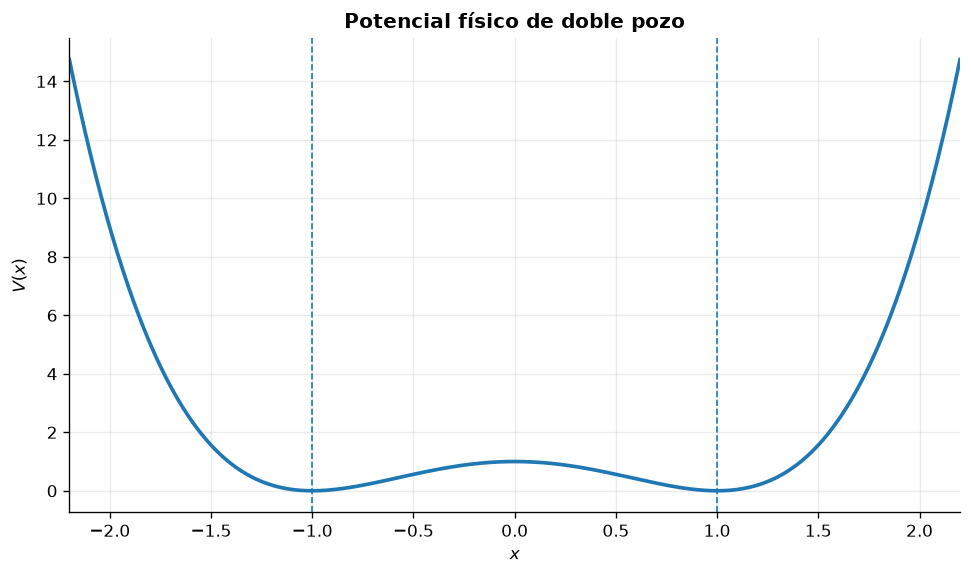

In [7]:
fig, ax = plt.subplots()
ax.plot(x_grid, potential_values, linewidth=2.2)
ax.axvline(-1.0, linestyle="--", linewidth=1.0)
ax.axvline(1.0, linestyle="--", linewidth=1.0)
ax.set(
    title="Potencial físico de doble pozo",
    xlabel=r"$x$",
    ylabel=r"$V(x)$",
    xlim=VALUE_RANGE,
)
finish_figure(fig, "double_well_potential")

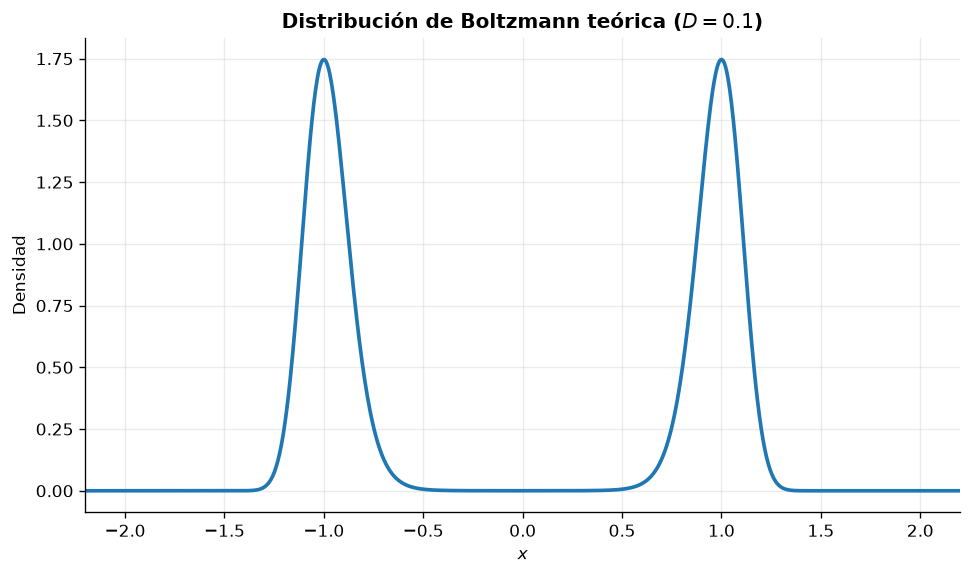

In [8]:
fig, ax = plt.subplots()
ax.plot(x_grid, theoretical_density, linewidth=2.2)
ax.set(
    title=rf"Distribución de Boltzmann teórica ($D={D:g}$)",
    xlabel=r"$x$",
    ylabel="Densidad",
    xlim=VALUE_RANGE,
)
finish_figure(fig, "double_well_theoretical_density")

## 2. ABP por metadinámica

No se proporciona un detector de transición porque el objetivo es estudiar la
distribución estacionaria durante un número fijo de pasos. El resultado es un
`ABPResult` inmutable que contiene posiciones, pesos, centros gaussianos y tiempo
físico reponderado.

In [9]:
ABP_STEPS = 40_000 if QUICK_MODE else 200_000

abp_simulation = ABPMetaDynamics(
    deposition_stride=100,
    transition_detector=None,
    delta_t=DELTA_T,
    dimension=1,
    D=D,
    initial_position=np.array([-1.0]),
    b=potential,
    W=0.01,
    sigma=0.15,
    seed=SEED,
)
abp_result = abp_simulation.run(max_steps=ABP_STEPS)

assert abp_result.n_steps == ABP_STEPS
assert len(abp_result.weights) == len(abp_result.positions)

print("terminación       :", abp_result.termination_reason)
print("pasos             :", abp_result.n_steps)
print("centros depositados:", len(abp_result.centers))
print("tiempo físico      :", f"{abp_result.physical_time:.6g}")

if SAVE_RESULTS:
    save_result(abp_result, RESULT_DIR / "abp_double_well")

terminación       : max_steps
pasos             : 40000
centros depositados: 400
tiempo físico      : 21591.8


### Trayectoria y depósitos de sesgo

La trayectoria muestra si el sesgo consigue abandonar el pozo inicial. Los centros
depositados revelan dónde la dinámica ha añadido gaussianas.

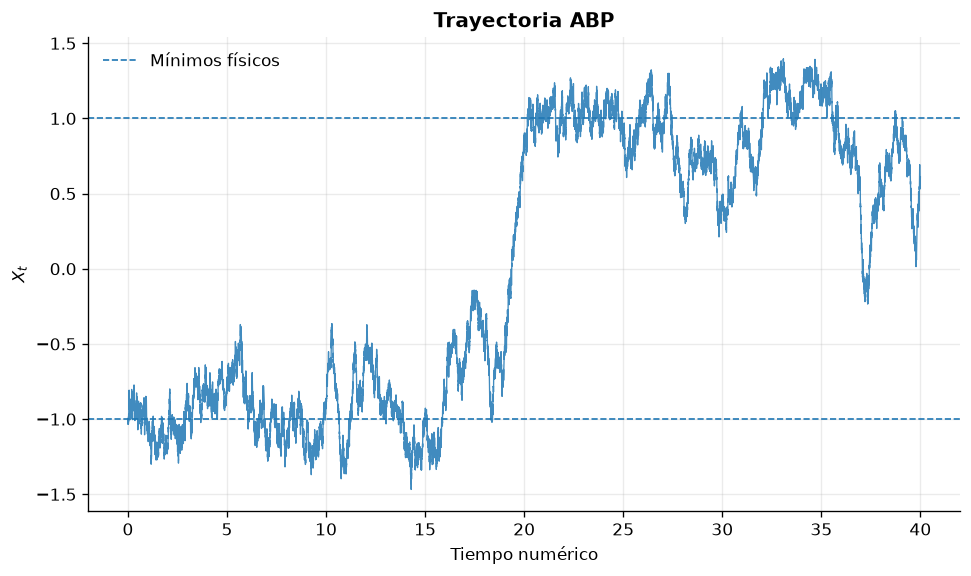

In [10]:
abp_positions = abp_result.positions[:, 0]
abp_time = np.arange(len(abp_positions)) * abp_result.delta_t

fig, ax = plt.subplots()
ax.plot(abp_time, abp_positions, linewidth=0.8, alpha=0.85)
ax.axhline(-1.0, linestyle="--", linewidth=1.0, label="Mínimos físicos")
ax.axhline(1.0, linestyle="--", linewidth=1.0)
ax.set(
    title="Trayectoria ABP",
    xlabel="Tiempo numérico",
    ylabel=r"$X_t$",
)
ax.legend()
finish_figure(fig, "abp_trajectory")

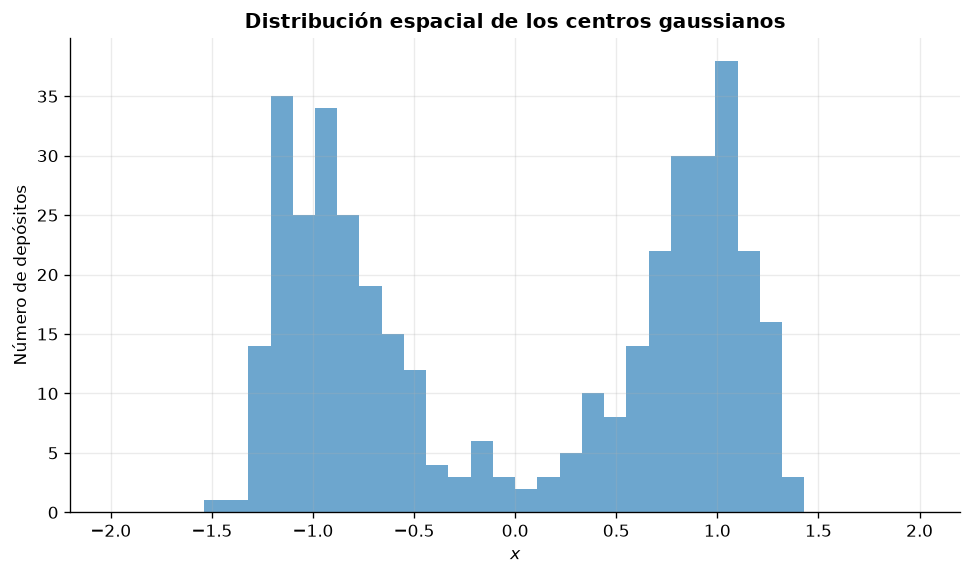

In [11]:
fig, ax = plt.subplots()
ax.hist(
    abp_result.centers[:, 0],
    bins=40,
    range=VALUE_RANGE,
    alpha=0.65,
)
ax.set(
    title="Distribución espacial de los centros gaussianos",
    xlabel=r"$x$",
    ylabel="Número de depósitos",
    xlim=VALUE_RANGE,
)
finish_figure(fig, "abp_deposition_centers")

### Potencial efectivo

Se evalúa el sesgo mediante la API del simulador ya entrenado. La suma
\(V+V_{bias}\) debería ser sensiblemente más plana en la región explorada.

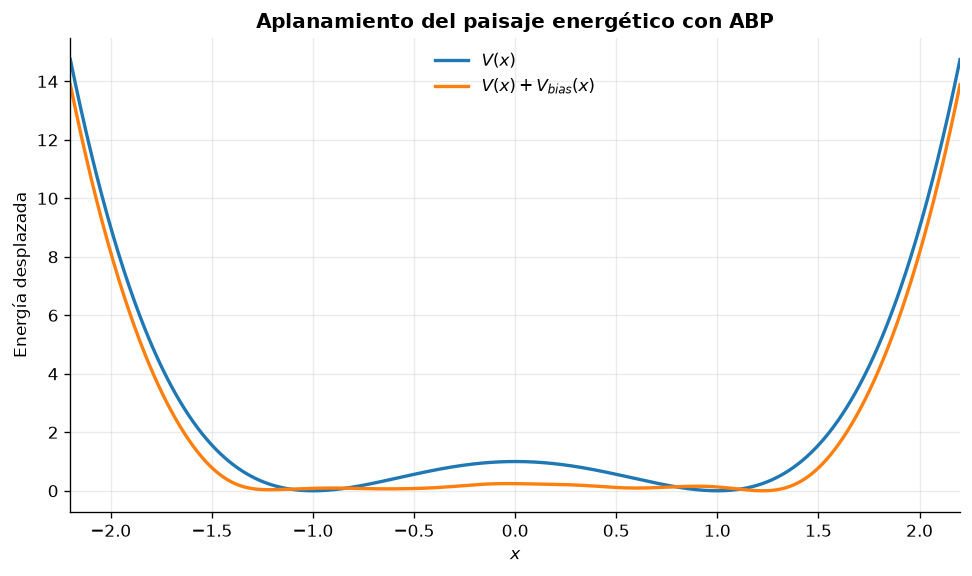

In [12]:
bias_values = np.array(
    [abp_simulation.bias_potential_at(np.array([x])) for x in x_grid]
)
effective_values = potential_values + bias_values

physical_shifted = potential_values - potential_values.min()
effective_shifted = effective_values - effective_values.min()

fig, ax = plt.subplots()
ax.plot(x_grid, physical_shifted, linewidth=2.0, label=r"$V(x)$")
ax.plot(
    x_grid,
    effective_shifted,
    linewidth=2.0,
    label=r"$V(x)+V_{bias}(x)$",
)
ax.set(
    title="Aplanamiento del paisaje energético con ABP",
    xlabel=r"$x$",
    ylabel="Energía desplazada",
    xlim=VALUE_RANGE,
)
ax.legend()
finish_figure(fig, "abp_effective_potential")

### Distribución sesgada y distribución reponderada

La trayectoria ABP no sigue directamente la distribución física. Los pesos
almacenados en `ABPResult` permiten reconstruirla. La distancia \(L^1\) ofrece un
indicador compacto de la concordancia con la densidad de Boltzmann.

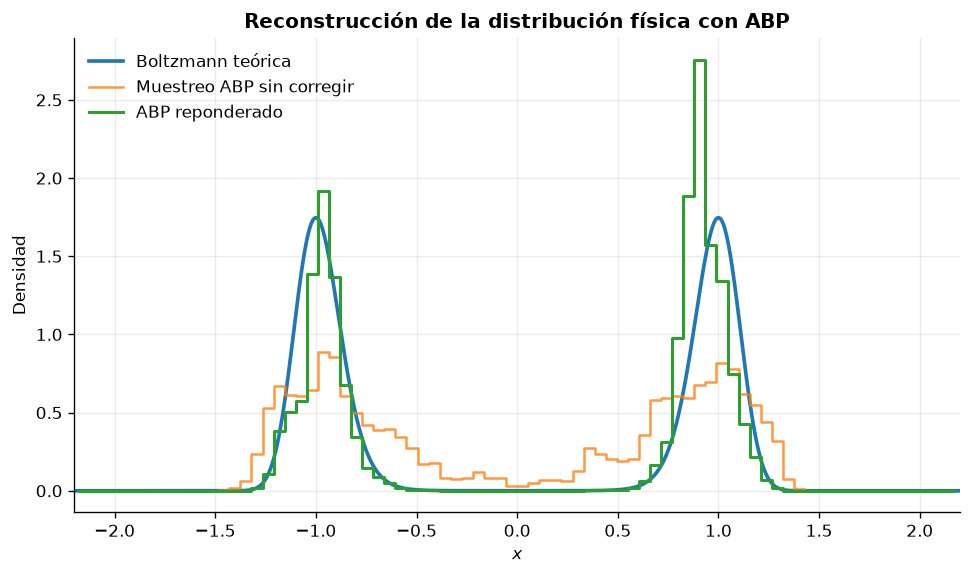

Distancia L1 sin reponderar : 0.77428
Distancia L1 reponderada    : 0.39478


In [13]:
histogram_kwargs = {
    "bins": 80,
    "value_range": VALUE_RANGE,
}

bin_centers, biased_density, _, bin_edges = weighted_histogram_density(
    values=abp_positions,
    weights=None,
    **histogram_kwargs,
)
weighted_centers, reweighted_density, _, _ = weighted_histogram_density(
    values=abp_positions,
    weights=abp_result.weights,
    **histogram_kwargs,
)
np.testing.assert_allclose(bin_centers, weighted_centers)

theory_on_bins = np.interp(bin_centers, x_grid, theoretical_density)
l1_biased = trapezoid(np.abs(biased_density - theory_on_bins), bin_centers)
l1_reweighted = trapezoid(
    np.abs(reweighted_density - theory_on_bins),
    bin_centers,
)

fig, ax = plt.subplots()
ax.plot(
    x_grid,
    theoretical_density,
    linewidth=2.2,
    label="Boltzmann teórica",
)
ax.step(
    bin_centers,
    biased_density,
    where="mid",
    alpha=0.8,
    label="Muestreo ABP sin corregir",
)
ax.step(
    bin_centers,
    reweighted_density,
    where="mid",
    linewidth=1.8,
    label="ABP reponderado",
)
ax.set(
    title="Reconstrucción de la distribución física con ABP",
    xlabel=r"$x$",
    ylabel="Densidad",
    xlim=VALUE_RANGE,
)
ax.legend()
finish_figure(fig, "abp_reweighted_density")

print(f"Distancia L1 sin reponderar : {l1_biased:.5f}")
print(f"Distancia L1 reponderada    : {l1_reweighted:.5f}")

In [14]:
weights = np.asarray(abp_result.weights, dtype=float)
effective_sample_size = weights.sum() ** 2 / np.dot(weights, weights)
effective_fraction = effective_sample_size / len(weights)

print(f"Tamaño muestral bruto       : {len(weights):,}")
print(f"Tamaño muestral efectivo    : {effective_sample_size:,.1f}")
print(f"Fracción muestral efectiva  : {effective_fraction:.2%}")

Tamaño muestral bruto       : 40,001
Tamaño muestral efectivo    : 3,868.8
Fracción muestral efectiva  : 9.67%


## 3. ABF en tiempo real

ABF estima en línea \(V'(x)\) por intervalos y construye un sesgo que cancela la
fuerza física. `out_of_range="clip"` limita únicamente la asignación de bin; la
trayectoria y la evaluación de la fuerza permanecen en la posición física real.

In [15]:
ABF_STEPS = 60_000 if QUICK_MODE else 300_000

abf_simulation = ABFRealTime(
    transition_detector=None,
    delta_t=DELTA_T,
    D=D,
    initial_position=np.array([-1.0]),
    b=potential,
    bins=100,
    value_range=VALUE_RANGE,
    seed=SEED + 1,
    profile_update_stride=25,
    out_of_range="clip",
)
abf_result = abf_simulation.run(max_steps=ABF_STEPS)

assert abf_result.n_steps == ABF_STEPS
assert int(abf_result.visit_counts.sum()) == ABF_STEPS

print("terminación  :", abf_result.termination_reason)
print("pasos        :", abf_result.n_steps)
print("tiempo físico:", f"{abf_result.physical_time:.6g}")

if SAVE_RESULTS:
    save_result(abf_result, RESULT_DIR / "abf_double_well")

terminación  : max_steps
pasos        : 60000
tiempo físico: 6.61352e+57


### Estimación de la derivada del potencial

Los bins con muy pocas visitas se excluyen de la comparación principal. El umbral
es un criterio de visualización, no una modificación del estimador.

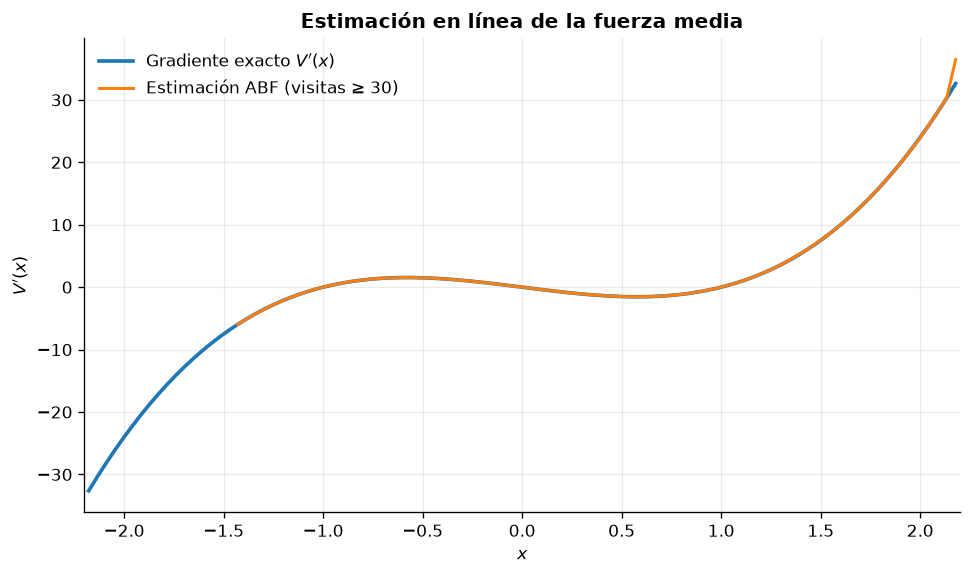

In [16]:
abf_bin_centers = 0.5 * (
    abf_result.bin_edges[:-1] + abf_result.bin_edges[1:]
)
true_gradient = np.array(
    [double_well_gradient(np.array([x]))[0] for x in abf_bin_centers]
)

MIN_VISITS = 30
sufficiently_visited = abf_result.visit_counts >= MIN_VISITS

fig, ax = plt.subplots()
ax.plot(
    abf_bin_centers,
    true_gradient,
    linewidth=2.2,
    label=r"Gradiente exacto $V'(x)$",
)
ax.plot(
    abf_bin_centers[sufficiently_visited],
    abf_result.force_bias[sufficiently_visited],
    linewidth=1.8,
    label=rf"Estimación ABF (visitas ≥ {MIN_VISITS})",
)
ax.set(
    title="Estimación en línea de la fuerza media",
    xlabel=r"$x$",
    ylabel=r"$V'(x)$",
    xlim=VALUE_RANGE,
)
ax.legend()
finish_figure(fig, "abf_force_estimate")

### Cobertura espacial

Una buena aproximación local no basta: también debe verificarse que la región de
interés haya sido visitada de forma suficiente.

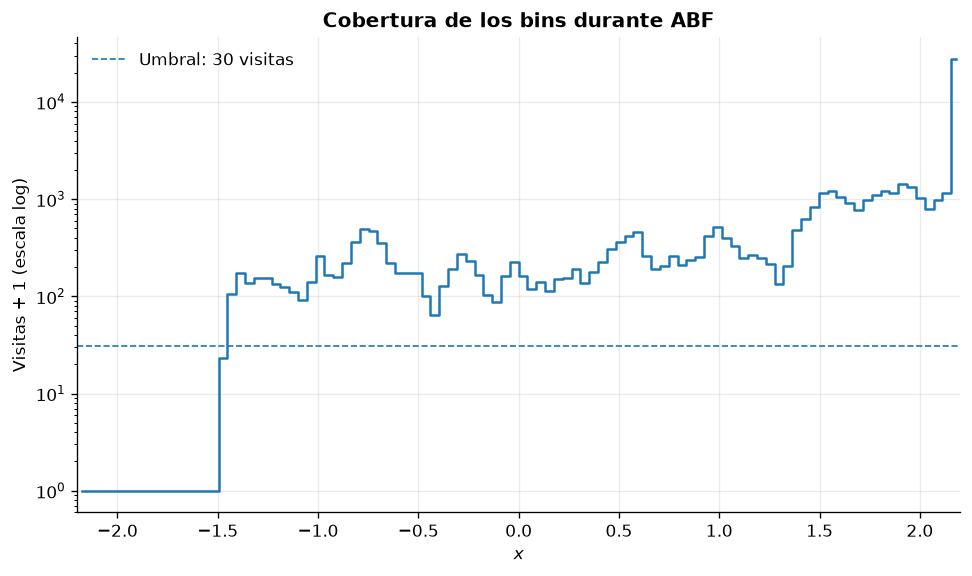

Bins visitados              : 84.0%
Bins con ≥ 30 visitas : 83.0%


In [17]:
fig, ax = plt.subplots()
ax.step(
    abf_bin_centers,
    abf_result.visit_counts + 1,
    where="mid",
    linewidth=1.5,
)
ax.axhline(
    MIN_VISITS + 1,
    linestyle="--",
    linewidth=1.0,
    label=f"Umbral: {MIN_VISITS} visitas",
)
ax.set_yscale("log")
ax.set(
    title="Cobertura de los bins durante ABF",
    xlabel=r"$x$",
    ylabel="Visitas + 1 (escala log)",
    xlim=VALUE_RANGE,
)
ax.legend()
finish_figure(fig, "abf_bin_coverage")

visited_fraction = np.mean(abf_result.visit_counts > 0)
well_sampled_fraction = np.mean(sufficiently_visited)
print(f"Bins visitados              : {visited_fraction:.1%}")
print(f"Bins con ≥ {MIN_VISITS} visitas : {well_sampled_fraction:.1%}")

### Perfil de energía libre

La energía libre se define salvo una constante aditiva. Por ello, ambos perfiles
se desplazan usando el mínimo sobre los bins suficientemente visitados.

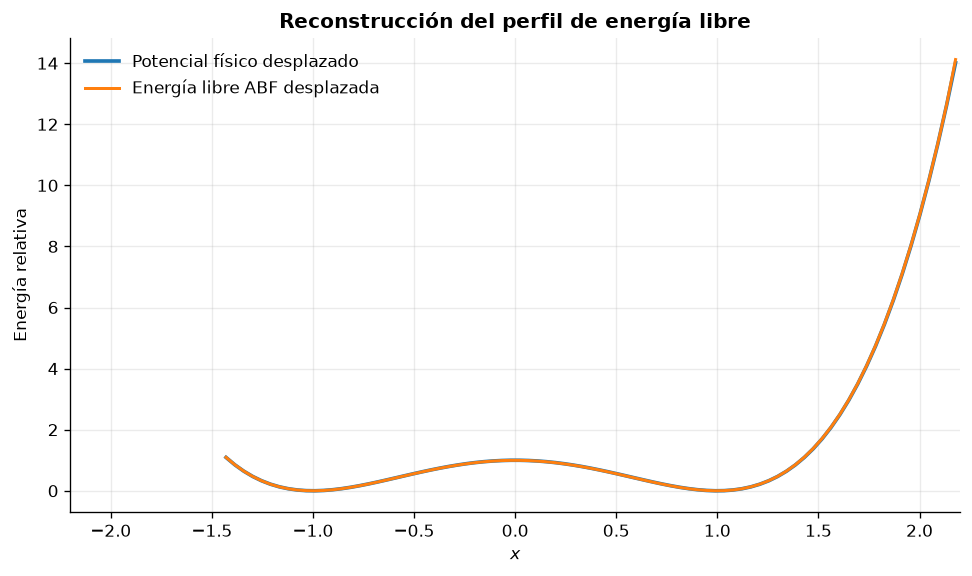

In [18]:
physical_on_bins = np.array(
    [double_well_value(np.array([x])) for x in abf_bin_centers]
)

if np.any(sufficiently_visited):
    estimated_free_energy = abf_result.free_energy.copy()
    estimated_free_energy -= estimated_free_energy[sufficiently_visited].min()

    physical_reference = physical_on_bins.copy()
    physical_reference -= physical_reference[sufficiently_visited].min()

    fig, ax = plt.subplots()
    ax.plot(
        abf_bin_centers[sufficiently_visited],
        physical_reference[sufficiently_visited],
        linewidth=2.2,
        label="Potencial físico desplazado",
    )
    ax.plot(
        abf_bin_centers[sufficiently_visited],
        estimated_free_energy[sufficiently_visited],
        linewidth=1.8,
        label="Energía libre ABF desplazada",
    )
    ax.set(
        title="Reconstrucción del perfil de energía libre",
        xlabel=r"$x$",
        ylabel="Energía relativa",
        xlim=VALUE_RANGE,
    )
    ax.legend()
    finish_figure(fig, "abf_free_energy")
else:
    print(
        "No hay bins con suficientes visitas. "
        "Aumenta ABF_STEPS o reduce MIN_VISITS."
    )

## 4. Persistencia reproducible

Las simulaciones largas no deberían quedar embebidas en el notebook. Para el
informe, el flujo recomendado es:

```bash
python scripts/run_reference_1d.py --steps 200000 --seed 2026
```

y posteriormente:

```python
result = load_result("../artifacts/reference_1d")
```

`save_result` guarda metadatos en JSON y arrays en NPZ comprimido. El notebook se
convierte así en una capa ligera de análisis y composición gráfica.

In [ ]:
# Ejemplo opcional de ida y vuelta:
#
# save_result(abp_result, RESULT_DIR / "abp_double_well")
# restored = load_result(RESULT_DIR / "abp_double_well")
# np.testing.assert_array_equal(restored.positions, abp_result.positions)

## Conclusiones que deben reportarse

- Si el potencial efectivo se aplana solo en una región estrecha, faltan pasos o
  los parámetros de depósito deben revisarse.
- La densidad ABP reponderada debe acercarse más a Boltzmann que la distribución
  sesgada sin corregir; la distancia \(L^1\) cuantifica esa mejora.
- En ABF, el error de fuerza debe interpretarse junto con el número de visitas.
- Las figuras finales deben producirse desde resultados persistidos y con
  `QUICK_MODE=False`, no desde ejecuciones ad hoc.